In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sympy import Matrix, pretty

In [2]:
# --- Load Data from Step 1 ---
A = np.load('../data/A_matrix.npy')
A_centered = np.load('../data/A_centered.npy')
player_names = pd.read_csv('../data/player_names.csv').iloc[:, 0].values
features = pd.read_csv('../data/features.csv').iloc[:, 0].values

print("Matrix A loaded successfully!")
print(f"Shape: {A.shape} → {A.shape[0]} players x {A.shape[1]} features")

Matrix A loaded successfully!
Shape: (1130, 10) → 1130 players x 10 features


In [3]:
# --- What is Matrix Simplification? ---
# We convert A into Row Reduced Echelon Form (RREF)
# This helps us identify:
#   1. Which stats are truly independent
#   2. Which stats can be derived from others
#   3. The rank of the matrix (number of independent patterns)

In [4]:
# --- Gaussian Elimination (Step by Step) ---
# We perform this on a small 5x5 sample to visualize clearly

sample = A_centered[:5, :5]
print("Sample 5x5 Matrix (first 5 players, first 5 features):")
print(pd.DataFrame(sample, 
                   index=player_names[:5], 
                   columns=features[:5]).round(2))

Sample 5x5 Matrix (first 5 players, first 5 features):
                 Matches_Batted  Runs_Scored  Batting_Average  \
Ruturaj Gaikwad           -7.02       -71.25            13.06   
Ruturaj Gaikwad            6.98       457.75            24.70   
Ruturaj Gaikwad            4.98       235.75             8.85   
Ruturaj Gaikwad            6.98       502.75            27.91   
Ruturaj Gaikwad           -3.02        71.75            33.56   

                 Batting_Strike_Rate  Wickets_Taken  
Ruturaj Gaikwad                17.30          -4.46  
Ruturaj Gaikwad                45.19          -4.46  
Ruturaj Gaikwad                24.15          -4.46  
Ruturaj Gaikwad                33.95          -4.46  
Ruturaj Gaikwad                18.40          -4.46  


In [6]:
# --- Convert to RREF using SymPy ---
# SymPy gives us exact RREF with fractions (clean output)

A_sympy = Matrix(A_centered.tolist())
A_rref, pivot_cols = A_sympy.rref()

print("RREF computed successfully!")
print(f"\nPivot Columns (Independent Features): {list(pivot_cols)}")
print(f"Pivot Feature Names: {[features[i] for i in pivot_cols]}")
print(f"\nNumber of Pivot Columns: {len(pivot_cols)}")

RREF computed successfully!

Pivot Columns (Independent Features): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Pivot Feature Names: ['Matches_Batted', 'Runs_Scored', 'Batting_Average', 'Batting_Strike_Rate', 'Wickets_Taken', 'Economy_Rate', 'Bowling_Average', 'Centuries', 'Half_Centuries', 'Catches_Taken']

Number of Pivot Columns: 10


In [8]:
# --- Rank of the Matrix ---
rank = len(pivot_cols)
num_rows, num_cols = A_centered.shape
nullity = num_cols - rank

print("=" * 45)
print(f"  Matrix Shape     : {num_rows} x {num_cols}")
print(f"  Rank             : {rank}")
print(f"  Nullity          : {nullity}")
print(f"  Rank + Nullity   : {rank + nullity} (= number of columns ✓)")
print("=" * 45)

print(f"""
Interpretation:
  → {rank} features are INDEPENDENT (pivot columns)
  → {nullity} features are DEPENDENT (free columns)
  → The rating data lives in a {rank}-dimensional subspace
""")

  Matrix Shape     : 1130 x 10
  Rank             : 10
  Nullity          : 0
  Rank + Nullity   : 10 (= number of columns ✓)

Interpretation:
  → 10 features are INDEPENDENT (pivot columns)
  → 0 features are DEPENDENT (free columns)
  → The rating data lives in a 10-dimensional subspace



LU Decomposition on 10x10 sample:

L (Lower Triangular) shape: (10, 10)
U (Upper Triangular) shape: (10, 10)


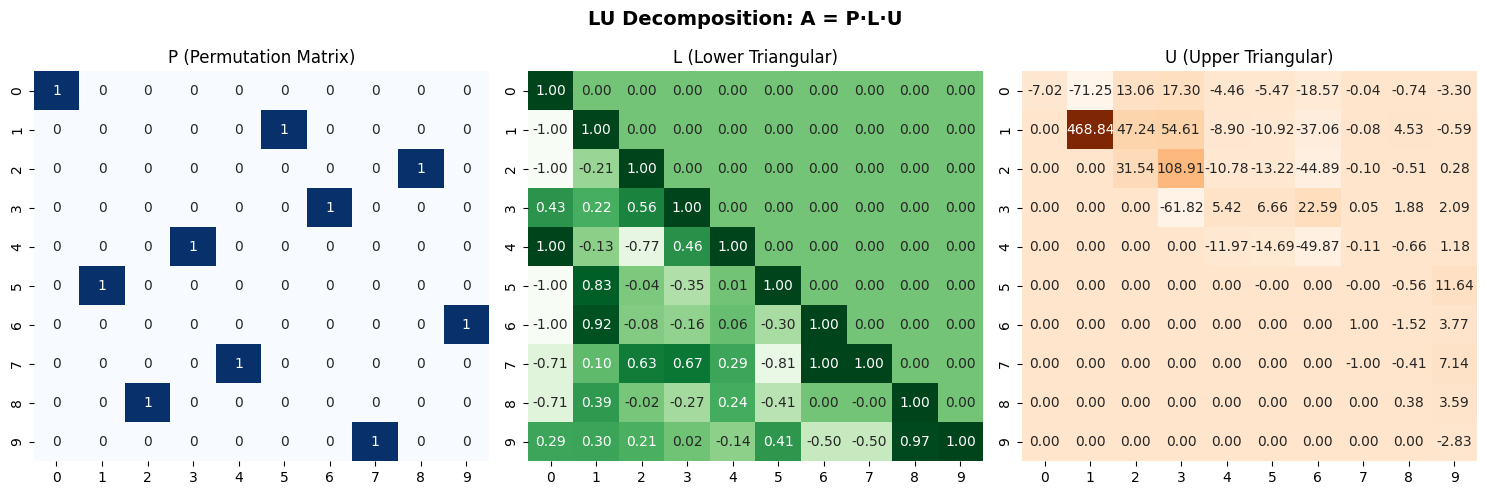

In [9]:
# --- LU Decomposition ---
# LU Decomposition factors A = L * U
# L = Lower triangular, U = Upper triangular
# This is a computational alternative to RREF

from scipy.linalg import lu

# Use a square subset for clean LU demo (10x10)
A_square = A_centered[:10, :10]
P, L, U = lu(A_square)

print("LU Decomposition on 10x10 sample:")
print(f"\nL (Lower Triangular) shape: {L.shape}")
print(f"U (Upper Triangular) shape: {U.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.heatmap(P, annot=True, fmt='.0f', ax=axes[0], 
            cmap='Blues', cbar=False)
axes[0].set_title('P (Permutation Matrix)')

sns.heatmap(np.round(L, 2), annot=True, fmt='.2f', ax=axes[1], 
            cmap='Greens', cbar=False)
axes[1].set_title('L (Lower Triangular)')

sns.heatmap(np.round(U, 2), annot=True, fmt='.2f', ax=axes[2], 
            cmap='Oranges', cbar=False)
axes[2].set_title('U (Upper Triangular)')

plt.suptitle('LU Decomposition: A = P·L·U', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step2_lu_decomposition.png', dpi=150)
plt.show()

In [10]:
# --- Verify LU: Reconstruct A from L and U ---
A_reconstructed = P @ L @ U
error = np.max(np.abs(A_square - A_reconstructed))

print(f"Max reconstruction error: {error:.2e}")
if error < 1e-10:
    print("✅ LU Decomposition verified — A = P·L·U is correct!")

Max reconstruction error: 5.68e-14
✅ LU Decomposition verified — A = P·L·U is correct!


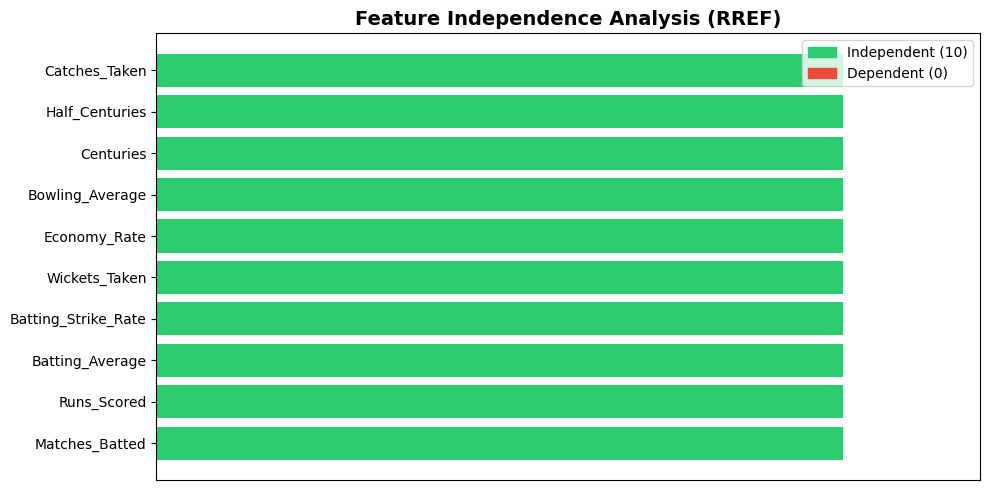


Independent Features: ['Matches_Batted', 'Runs_Scored', 'Batting_Average', 'Batting_Strike_Rate', 'Wickets_Taken', 'Economy_Rate', 'Bowling_Average', 'Centuries', 'Half_Centuries', 'Catches_Taken']
Dependent Features  : []


In [11]:
# --- Visualize Independent vs Dependent Features ---
independent_features = [features[i] for i in pivot_cols]
dependent_features = [f for f in features if f not in independent_features]

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if f in independent_features 
          else '#e74c3c' for f in features]

ax.barh(features, [1] * len(features), color=colors)
ax.set_xlabel('')
ax.set_title('Feature Independence Analysis (RREF)', 
             fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label=f'Independent ({len(independent_features)})'),
          Patch(color='#e74c3c', label=f'Dependent ({len(dependent_features)})')]
ax.legend(handles=legend)
ax.set_xlim(0, 1.2)
ax.set_xticks([])

plt.tight_layout()
plt.savefig('../outputs/step2_feature_independence.png', dpi=150)
plt.show()

print(f"\nIndependent Features: {independent_features}")
print(f"Dependent Features  : {dependent_features}")

In [12]:
# --- Save Results for Step 3 ---
np.save('../data/pivot_cols.npy', np.array(pivot_cols))
np.save('../data/rank.npy', np.array(rank))

print("✅ Step 2 Complete!")
print(f"   → Rank of matrix        : {rank}")
print(f"   → Nullity               : {nullity}")
print(f"   → Independent features  : {independent_features}")
print("   → Ready for Step 3: Structure of the Space")

✅ Step 2 Complete!
   → Rank of matrix        : 10
   → Nullity               : 0
   → Independent features  : ['Matches_Batted', 'Runs_Scored', 'Batting_Average', 'Batting_Strike_Rate', 'Wickets_Taken', 'Economy_Rate', 'Bowling_Average', 'Centuries', 'Half_Centuries', 'Catches_Taken']
   → Ready for Step 3: Structure of the Space
